In [1]:
import os
import pandas as pd
import seaborn as sns

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import matplotlib

In [5]:
matplotlib.rcParams['pdf.fonttype'] = 42

In [6]:
models = [
    'expimap', 
    'GPformer',
    'spectra',
]

In [7]:
def find_and_load_csvs(directories):
    dataframes = []
    
    # Loop through the list of directories
    eval_types = ['knn', 'logistic_regression']
    runs = ['run_1', 'run_2', 'run_3']
    
    tasks = ['', '_top_1', '_top_2', '_top_3', '_top_4', '_top_5', ] # '_top_10'
    
    for m in models:
        for r in runs:
            for e in eval_types:
                for t in tasks:
                    directory = os.path.join(m, r, f'{e}{t}')

                    # now load csv files:
                    for filename in os.listdir(directory):

                        # Check if the file has a .csv extension
                        if filename.endswith('.csv'):
                            file_path = os.path.join(directory, filename)

                            label_type, gp = filename.replace('.csv', '').replace('from_', '').split('id_')

                            df = pd.read_csv(file_path)
                            df['model'] = m
                            df['eval_type'] = e
                            df['task'] = 'target_pathway' if t == '' else f'gene{t}'
                            df['label_type'] = label_type
                            df['gp'] = gp
                            df['run'] = r

                            dataframes.append(df)
        
    dataframes = pd.concat(dataframes)
    
    return dataframes

In [8]:

results = find_and_load_csvs(models)

In [9]:
results

,output_class,metric,value,accuracy,model,eval_type,task,label_type,gp,run
0,TGFb,precision,0.653575,0.761957,expimap,knn,target_pathway,target_pathway_,TNFa,run_1
1,TGFb,recall,0.797860,0.761957,expimap,knn,target_pathway,target_pathway_,TNFa,run_1
2,TGFb,f1-score,0.718546,0.761957,expimap,knn,target_pathway,target_pathway_,TNFa,run_1
3,TGFb,support,23736.000000,0.761957,expimap,knn,target_pathway,target_pathway_,TNFa,run_1
4,TNFa,precision,0.856128,0.761957,expimap,knn,target_pathway,target_pathway_,TNFa,run_1
...,...,...,...,...,...,...,...,...,...,...
19,MAPK8,support,780.000000,0.074517,spectra,logistic_regression,gene_top_5,gene_,TNFa,run_3
20,TNFRSF1A,precision,0.052581,0.074517,spectra,logistic_regression,gene_top_5,gene_,TNFa,run_3
21,TNFRSF1A,recall,0.753425,0.074517,spectra,logistic_regression,gene_top_5,gene_,TNFa,run_3
22,TNFRSF1A,f1-score,0.098302,0.074517,spectra,logistic_regression,gene_top_5,gene_,TNFa,run_3


In [10]:
results['model'] = np.where(
    results['model'] == 'expimap', 'Expimap', results['model']
)

In [11]:
results['model'] = np.where(
    results['model'] == 'spectra', 'Spectra', results['model']
)

# Logistic regression

/tmp/ipykernel_2713061/3383431053.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
/tmp/ipykernel_2713061/3383431053.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax, palette=custom_colors,
/tmp/ipykernel_2713061/3383431053.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_2713061/3383431053.py:12: FutureWarning: 

Pa

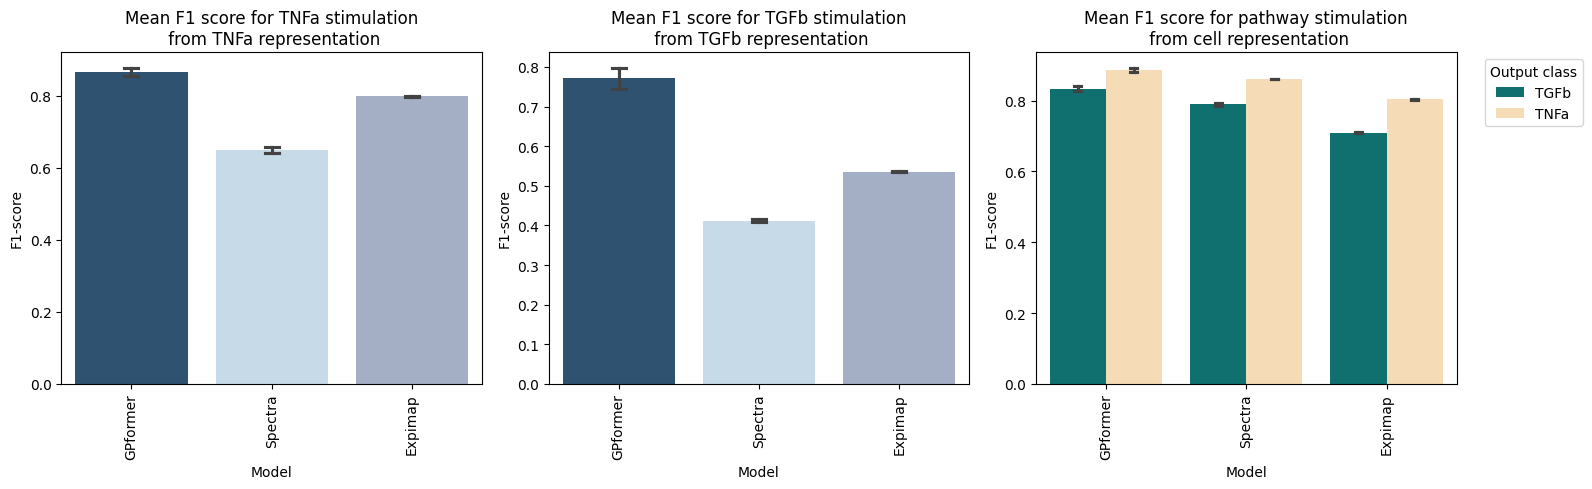

In [12]:
df = results 
df = df[df['eval_type'] == 'logistic_regression']

# Define the desired order for the x-axis
model_order = ["GPformer", "Spectra", "Expimap"]

# Convert 'model' column to categorical type with the specified order
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Define a function to create bar plots with error bars
def plot_bar(ax, df, x, y, hue=None, title=None, xlabel=None, ylabel=None, custom_colors=None):
    sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax, palette=custom_colors, 
                errorbar='sd',
                capsize=0.1, order=model_order)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel if xlabel else '')
    ax.set_ylabel(ylabel if ylabel else y)
    ax.tick_params(axis='x', rotation=90)
    
    # Convert error values to numeric to avoid dtype issues
    if hue:
        ax.legend(title="Output class", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().remove()

# Top row figure
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))

plot_configs = [
    {"gp": "TNFa", "task": "target_pathway", "output_class": "TNFa", "metric": "f1-score", 
     "title": "Mean F1 score for TNFa stimulation\n from TNFa representation"},
    {"gp": "TGFb", "task": "target_pathway", "output_class": "TGFb", "metric": "f1-score", 
     "title": "Mean F1 score for TGFb stimulation\n from TGFb representation"},
    {'gp': 'cell_token', 'task' : 'target_pathway', 'output_class' : 'all', "metric": "f1-score", 
     "title": "Mean F1 score for pathway stimulation\n from cell representation"
    }
]

bar_colors_tnfa = {
    'GPformer': '#25527c',
    'Expimap': '#9eadcc',
    'Spectra': '#c1dbed',
}

bar_colors_tgfb = {
    'GPformer': '#25527c',
    'Expimap': '#9eadcc',
    'Spectra': '#c1dbed',
}


for i, config in enumerate(plot_configs):
    filtered_df = df[(df['gp'] == config['gp']) & (df['task'] == config['task']) & 
                     (df['metric'] == config['metric'])]
    
    if config['output_class'] != 'all':
        filtered_df = filtered_df[filtered_df['output_class'] == config['output_class']]
        plot_bar(axes1[i], filtered_df, x='model', y='value', title=config['title'], xlabel='Model', ylabel='F1-score', 
                 custom_colors=bar_colors_tnfa if config['output_class'] == 'TNFa' else bar_colors_tgfb)
    
    else:
        class_colors = {
            'TGFb' : 'teal',
            'TNFa' : 'navajowhite'
        }
        plot_bar(axes1[i], filtered_df, x='model', y='value', title=config['title'], xlabel='Model', ylabel='F1-score', custom_colors=class_colors,
                hue = 'output_class')

plt.tight_layout()

# plt.savefig('eval_target_pathway.pdf')

plt.show()


/tmp/ipykernel_2713061/355499519.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
/tmp/ipykernel_2713061/355499519.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2713061/355499519.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


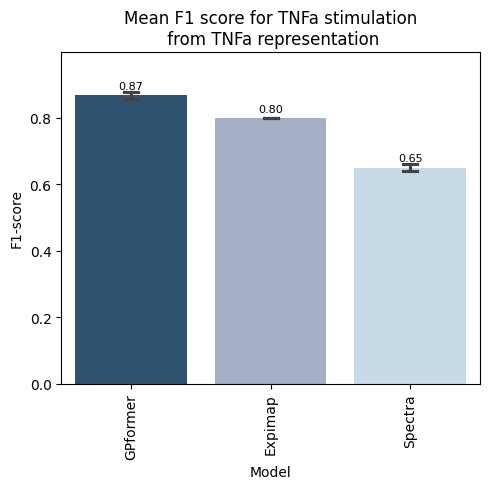

/tmp/ipykernel_2713061/355499519.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2713061/355499519.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


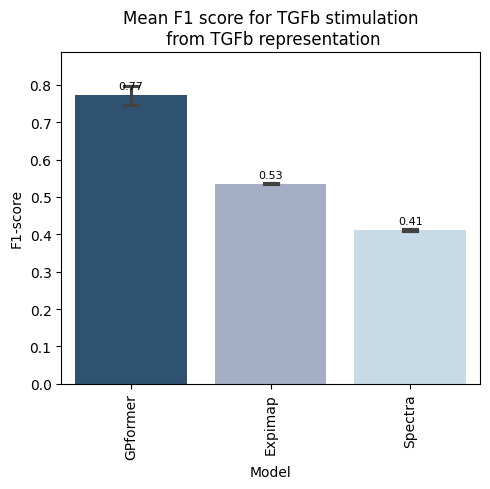

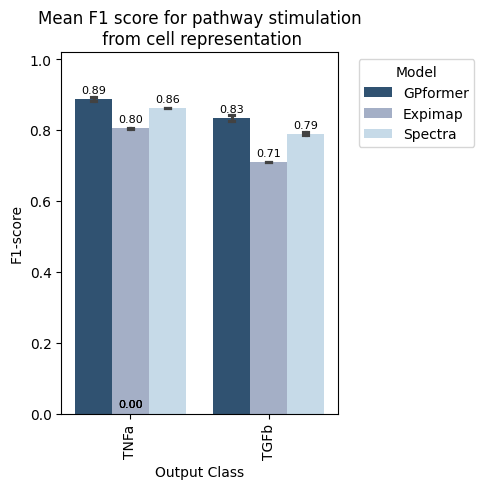

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = results 
df = df[df['eval_type'] == 'logistic_regression']

model_order = ["GPformer", "Expimap", "Spectra", ]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

def plot_bar(ax, df, x, y, hue=None, title=None, xlabel=None, ylabel=None, custom_colors=None):
    hue_order = model_order if hue == 'model' else None
    x_order = ['TNFa', 'TGFb'] if x == 'output_class' else model_order

    sns.barplot(
        data=df,
        x=x, y=y, hue=hue, ax=ax,
        palette=custom_colors,
        errorbar='sd', capsize=0.1,
        hue_order=hue_order,
        order=x_order
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel if xlabel else '')
    ax.set_ylabel(ylabel if ylabel else y)
    ax.tick_params(axis='x', rotation=90)

    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.annotate(f'{height:.2f}',
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8,
                        xytext=(0, 3), textcoords='offset points')

    y_max = max([p.get_height() for p in ax.patches if not pd.isna(p.get_height())]) * 1.15
    ax.set_ylim(0, y_max)

    if hue:
        ax.legend(title=hue.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().remove()


# Plot configuration
plot_configs = [
    {"gp": "TNFa", "task": "target_pathway", "output_class": "TNFa", "metric": "f1-score", 
     "title": "Mean F1 score for TNFa stimulation\n from TNFa representation", "filename": "f1_TNFa.pdf"},
    {"gp": "TGFb", "task": "target_pathway", "output_class": "TGFb", "metric": "f1-score", 
     "title": "Mean F1 score for TGFb stimulation\n from TGFb representation", "filename": "f1_TGFb.pdf"},
    {'gp': 'cell_token', 'task' : 'target_pathway', 'output_class' : 'all', "metric": "f1-score", 
     "title": "Mean F1 score for pathway stimulation\n from cell representation", "filename": "f1_cell.pdf"
    }
]

bar_colors_tnfa = {
    'GPformer': '#25527c',
    'Expimap': '#9eadcc',
    'Spectra': '#c1dbed',
}

bar_colors_tgfb = {
    'GPformer': '#25527c',
    'Expimap': '#9eadcc',
    'Spectra': '#c1dbed',
}

class_colors = {
    'TGFb' : 'teal',
    'TNFa' : 'navajowhite'
}
for config in plot_configs:
    fig, ax = plt.subplots(figsize=(5, 5))
    filtered_df = df[(df['gp'] == config['gp']) & (df['task'] == config['task']) & 
                     (df['metric'] == config['metric'])]

    if config['output_class'] != 'all':
        filtered_df = filtered_df[filtered_df['output_class'] == config['output_class']]
        plot_bar(ax, filtered_df, x='model', y='value', title=config['title'], xlabel='Model', ylabel='F1-score', 
                 custom_colors=bar_colors_tnfa if config['output_class'] == 'TNFa' else bar_colors_tgfb)
    else:
        # f1_cell case: show output_class on x-axis and model as hue
        filtered_df = filtered_df[filtered_df['output_class'].isin(['TNFa', 'TGFb'])]

        plot_bar(ax, 
                 filtered_df, 
                 x='output_class', 
                 y='value', 
                 hue='model',
                 title=config['title'], xlabel='Output Class', ylabel='F1-score',
                 custom_colors=bar_colors_tnfa)  # use model color palette

    
    plt.tight_layout()
    plt.savefig(config['filename'])
    plt.show()
    plt.close(fig)



In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define model order and a single (blue) color scheme
model_order = ['GPformer', 'Expimap', 'Spectra']
blue_palette = {
    'GPformer': '#25527c',
    'Expimap': '#9eadcc',
    'Spectra': '#c1dbed',
}

def generate_gene_plot(gp_name):
    """
    Generate a line+dot plot with error bars for a given genetic perturbation name.
    
    Parameters:
        gp_name (str): Name of the GP signal (e.g., 'TNFa', 'TGFb')
        
    Returns:
        ax (matplotlib.axes._subplots.AxesSubplot): The matplotlib Axes object.
    """
    # Filter data
    filtered_df = df[
        (df['gp'] == gp_name) &
        (df['task'].str.startswith('gene_top_')) &
        (df['output_class'] == 'NT') &
        (df['metric'] == 'f1-score')
    ].copy()

    # Extract top_k from task name
    filtered_df['gene_top_k'] = filtered_df['task'].str.extract(r'gene_top_(\d+)')[0].astype(int)

    # Aggregate by mean and std
    summary = (
        filtered_df
        .groupby(['gene_top_k', 'model'])['value']
        .agg(['mean', 'std'])
        .reset_index()
    )

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(5, 3))

    # Plot for each model
    for model in model_order:
        model_data = summary[summary['model'] == model]

        # Line
        ax.plot(
            model_data['gene_top_k'],
            model_data['mean'],
            label=model,
            color=blue_palette[model],
            linewidth=2
        )
        
        # Dots only
        ax.scatter(
            model_data['gene_top_k'],
            model_data['mean'],
            color=blue_palette[model],
            s=40
        )

        # Dots with error bars
        ax.errorbar(
            model_data['gene_top_k'],
            model_data['mean'],
            yerr=model_data['std'],
            fmt='o',
            capsize=3,
            color=blue_palette[model]
        )

    # Formatting
    ax.set_title(f"Mean F1 score for genetic perturbation classification\nfrom {gp_name} representation", fontsize=12)
    ax.set_xlabel('Genes with top K strongest perturbation effect')
    ax.set_ylabel('F1-score')
    ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    return ax


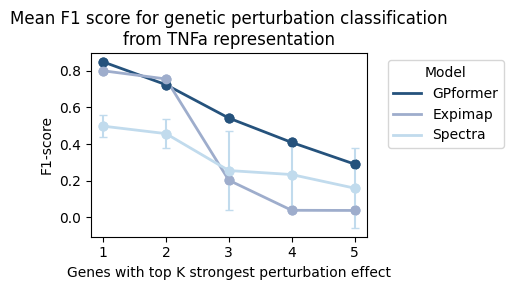

In [15]:
generate_gene_plot('TNFa')
plt.savefig('genetic_classification_tnfa.pdf')
plt.show()


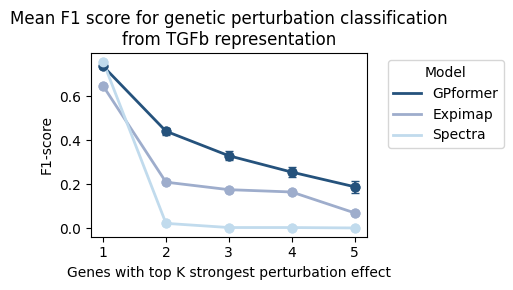

In [16]:
generate_gene_plot('TGFb')
plt.savefig('genetic_classification_tgb.pdf')
plt.show()


In [17]:
# Baselines: gene expression

In [26]:
models = ['log_expr', 'score_genes']

In [27]:
def find_and_load_baselines(directories):
    dataframes = []
    
    # Loop through the list of directories
    eval_types = [
        # 'knn', 
        'logistic_regression']
    
    tasks = ['', '_top_1', '_top_2', '_top_3', '_top_4', '_top_5', ] # '_top_10'
    
    for m in models:
        for r in ['']:
            for e in eval_types:
                for t in tasks:
                    directory = os.path.join(m, r, f'{e}{t}')

                    # now load csv files:
                    for filename in os.listdir(directory):

                        # Check if the file has a .csv extension
                        if filename.endswith('.csv'):
                            file_path = os.path.join(directory, filename)

                            label_type, gp = filename.replace('.csv', '').replace('from_', '').split('id_')

                            df = pd.read_csv(file_path)
                            df['model'] = m
                            df['eval_type'] = e
                            df['task'] = 'target_pathway' if t == '' else f'gene{t}'
                            df['label_type'] = label_type
                            df['gp'] = gp
                            df['run'] = r

                            dataframes.append(df)
        
    dataframes = pd.concat(dataframes)
    
    return dataframes

In [28]:
baselines = find_and_load_baselines(models)

/tmp/ipykernel_2713061/83586573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax, palette=custom_colors,
/tmp/ipykernel_2713061/83586573.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_2713061/83586573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax, palette=custom_colors,
/tmp/ipykernel_2713061/83586573.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored w

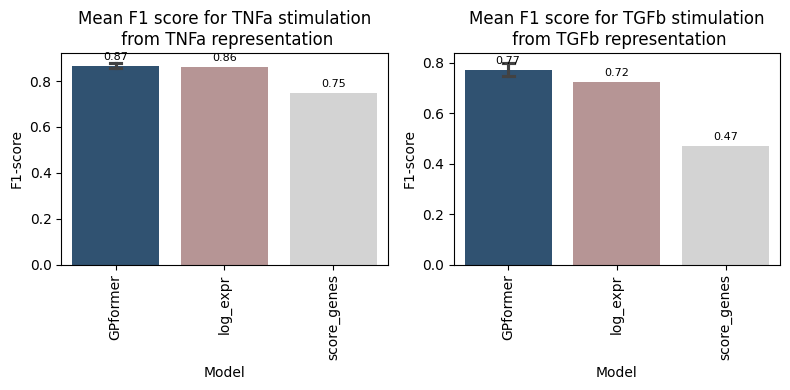

In [33]:
df = pd.concat([results[results['model'] == 'GPformer'], baselines])
df = df[df['eval_type'] == 'logistic_regression']

# Define the desired order for the x-axis
model_order = ["GPformer", "log_expr", "score_genes"]

# Convert 'model' column to categorical type with the specified order
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Define a function to create bar plots with error bars and annotate bars with raw values
def plot_bar(ax, df, x, y, hue=None, title=None, xlabel=None, ylabel=None, custom_colors=None):
    bar = sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax, palette=custom_colors, 
                errorbar='sd',
                capsize=0.1, order=model_order)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel if xlabel else '')
    ax.set_ylabel(ylabel if ylabel else y)
    ax.tick_params(axis='x', rotation=90)
    
    # Annotate each bar with its raw value
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.annotate(f'{height:.2f}',
                        (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8,
                        xytext=(0, 3), textcoords='offset points')
    
    # Convert error values to numeric to avoid dtype issues
    if hue:
        ax.legend(title="Output class", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().remove()

# Top row figure
fig1, axes1 = plt.subplots(1, 2, figsize=(8, 4))

plot_configs = [
    {"gp": "TNFa", "task": "target_pathway", "output_class": "TNFa", "metric": "f1-score", 
     "title": "Mean F1 score for TNFa stimulation\n from TNFa representation"},
    {"gp": "TGFb", "task": "target_pathway", "output_class": "TGFb", "metric": "f1-score", 
     "title": "Mean F1 score for TGFb stimulation\n from TGFb representation"},
]

bar_colors_tnfa = {
    'GPformer': '#25527c',
    'log_expr': 'rosybrown',
    'score_genes': 'lightgray',
}

bar_colors_tgfb = bar_colors_tnfa

for i, config in enumerate(plot_configs):
    filtered_df = df[(df['gp'] == config['gp']) & (df['task'] == config['task']) & 
                     (df['metric'] == config['metric'])]
    
    if config['output_class'] != 'all':
        filtered_df = filtered_df[filtered_df['output_class'] == config['output_class']]
        plot_bar(axes1[i], filtered_df, x='model', y='value', title=config['title'], xlabel='Model', ylabel='F1-score', 
                 custom_colors=bar_colors_tnfa if config['output_class'] == 'TNFa' else bar_colors_tgfb)
    
    else:
        class_colors = {
            'TGFb' : 'teal',
            'TNFa' : 'navajowhite'
        }
        plot_bar(axes1[i], filtered_df, x='model', y='value', title=config['title'], xlabel='Model', ylabel='F1-score', custom_colors=class_colors,
                hue = 'output_class')

plt.tight_layout()

plt.savefig('baselines.pdf')

plt.show()
